In [2]:
import pandas as pd #for data analysis and manipulation
import numpy as np #for arrays, matrices, maths
import matplotlib.pyplot as plt #for visulzation
#%matplotlib inline
import seaborn as sns #for visulzation
#sns.set() #toset default themes
import warnings #to manage warnings
warnings.filterwarnings("ignore")

In [3]:
#loading the dataset in variable
hs = pd.read_csv("E:\Datasets\Huggingface\Health care\GlobalLeadershipProject_v1.csv")

In [4]:
#Checking the frist five rows
hs.head()

,Available Extra Rooms in Hospital,Department,Ward_Facility_Code,doctor_name,staff_available,patientid,Age,gender,Type of Admission,Severity of Illness,health_conditions,Visitors with Patient,Insurance,Admission_Deposit,Stay (in days)
0,4,gynecology,D,Dr Sophia,0,33070,41-50,Female,Trauma,Extreme,Diabetes,4,Yes,2966.408696,8
1,4,gynecology,B,Dr Sophia,2,34808,31-40,Female,Trauma,Minor,Heart disease,2,No,3554.835677,9
2,2,gynecology,B,Dr Sophia,8,44577,21-30,Female,Trauma,Extreme,Diabetes,2,Yes,5624.733654,7
3,4,gynecology,D,Dr Olivia,7,3695,31-40,Female,Urgent,Moderate,NaN,4,No,4814.149231,8
4,2,anesthesia,E,Dr Mark,10,108956,71-80,Male,Trauma,Moderate,Diabetes,2,No,5169.269637,34


In [5]:
h4 = hs.copy()

In [6]:
#copying the data into another variable
#h = hs.copy()

In [7]:
#checkig the data type
h4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 15 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Available Extra Rooms in Hospital  500000 non-null  int64  
 1   Department                         500000 non-null  object 
 2   Ward_Facility_Code                 500000 non-null  object 
 3   doctor_name                        500000 non-null  object 
 4   staff_available                    500000 non-null  int64  
 5   patientid                          500000 non-null  int64  
 6   Age                                500000 non-null  object 
 7   gender                             500000 non-null  object 
 8   Type of Admission                  500000 non-null  object 
 9   Severity of Illness                500000 non-null  object 
 10  health_conditions                  348112 non-null  object 
 11  Visitors with Patient              5000

In [8]:
#checking the shape of the data
h4.shape

(500000, 15)

In [9]:
#checking stats of data
h4.describe()

,Available Extra Rooms in Hospital,staff_available,patientid,Visitors with Patient,Admission_Deposit,Stay (in days)
count,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000
mean,3.638800,5.020470,63150.519058,3.549414,4722.315734,12.381062
std,2.698124,3.158103,41689.479956,2.241054,1047.324220,7.913174
min,0.000000,0.000000,-3269.000000,0.000000,1654.005148,3.000000
25%,2.000000,2.000000,25442.000000,2.000000,4071.714532,8.000000
50%,3.000000,5.000000,57864.000000,3.000000,4627.003792,9.000000
75%,4.000000,8.000000,103392.000000,4.000000,5091.612717,11.000000
max,24.000000,10.000000,134400.000000,32.000000,10104.726390,51.000000


In [10]:
#cheking the null values
h4.isnull().sum()

Available Extra Rooms in Hospital         0
Department                                0
Ward_Facility_Code                        0
doctor_name                               0
staff_available                           0
patientid                                 0
Age                                       0
gender                                    0
Type of Admission                         0
Severity of Illness                       0
health_conditions                    151888
Visitors with Patient                     0
Insurance                                 0
Admission_Deposit                         0
Stay (in days)                            0
dtype: int64

In [11]:
#checking the null percent of the data
null_percent = h4.isnull().sum() /len(h4) * 100
null_percent

Available Extra Rooms in Hospital     0.0000
Department                            0.0000
Ward_Facility_Code                    0.0000
doctor_name                           0.0000
staff_available                       0.0000
patientid                             0.0000
Age                                   0.0000
gender                                0.0000
Type of Admission                     0.0000
Severity of Illness                   0.0000
health_conditions                    30.3776
Visitors with Patient                 0.0000
Insurance                             0.0000
Admission_Deposit                     0.0000
Stay (in days)                        0.0000
dtype: float64

In [12]:
#dropping the column above 25% missing value
h4['health_conditions'] = h4['health_conditions'].fillna('Other')

In [13]:
#checking the columns in dataset
h4.columns

Index(['Available Extra Rooms in Hospital', 'Department', 'Ward_Facility_Code',
       'doctor_name', 'staff_available', 'patientid', 'Age', 'gender',
       'Type of Admission', 'Severity of Illness', 'health_conditions',
       'Visitors with Patient', 'Insurance', 'Admission_Deposit',
       'Stay (in days)'],
      dtype='object')

In [14]:
h4.sample(5)

,Available Extra Rooms in Hospital,Department,Ward_Facility_Code,doctor_name,staff_available,patientid,Age,gender,Type of Admission,Severity of Illness,health_conditions,Visitors with Patient,Insurance,Admission_Deposit,Stay (in days)
294092,2,gynecology,D,Dr Sarah,4,122557,11-20,Female,Trauma,Minor,Asthama,2,No,4186.220843,9
317584,3,radiotherapy,A,Dr Sam,2,115604,71-80,Male,Trauma,Extreme,Asthama,2,Yes,4309.946320,22
43304,5,gynecology,D,Dr Nathan,4,29437,31-40,Female,Emergency,Minor,Other,4,Yes,3899.998408,8
50437,2,gynecology,D,Dr Sarah,4,301,31-40,Female,Urgent,Minor,High Blood Pressure,9,Yes,3477.325394,7
70307,3,gynecology,F,Dr Sophia,4,19964,21-30,Female,Emergency,Minor,Diabetes,8,Yes,4498.739579,7


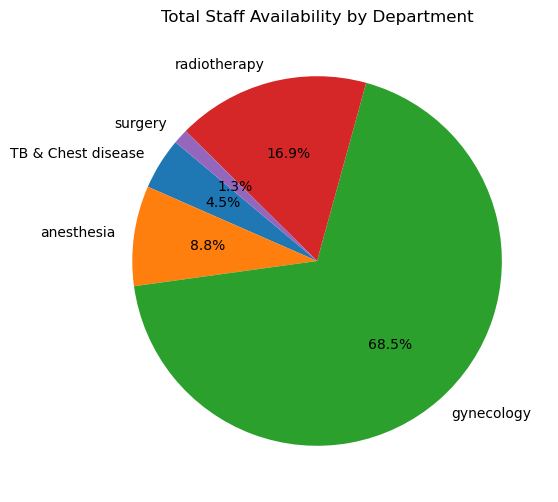

In [15]:
#Pie plot for department wise staff availability
pie_data = h4.groupby('Department')['staff_available'].sum()


plt.figure(figsize=(8, 6))
plt.pie(pie_data, labels=pie_data.index, autopct='%1.1f%%', startangle=140)
plt.title("Total Staff Availability by Department")
plt.show()


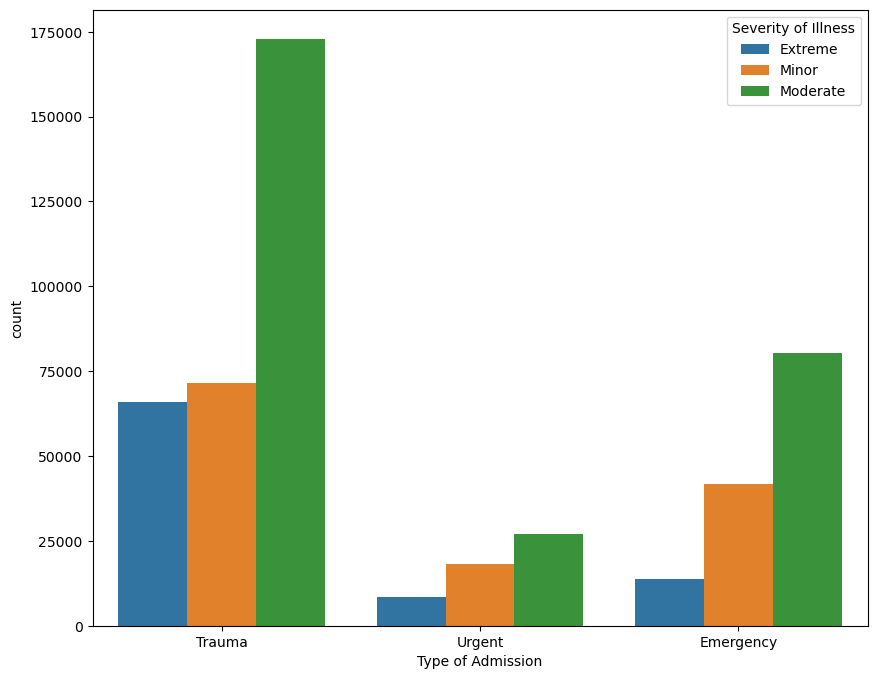

In [16]:
#bar plot for type of admisison of severiate of illness patients
plt.figure(figsize=(10,8))
sns.countplot(data = h4, x = 'Type of Admission', hue = 'Severity of Illness')
plt.show()

We can observe majority admissions are moderate level in hosital are falls in Trauma and same for uregnt type of admission and emergency.


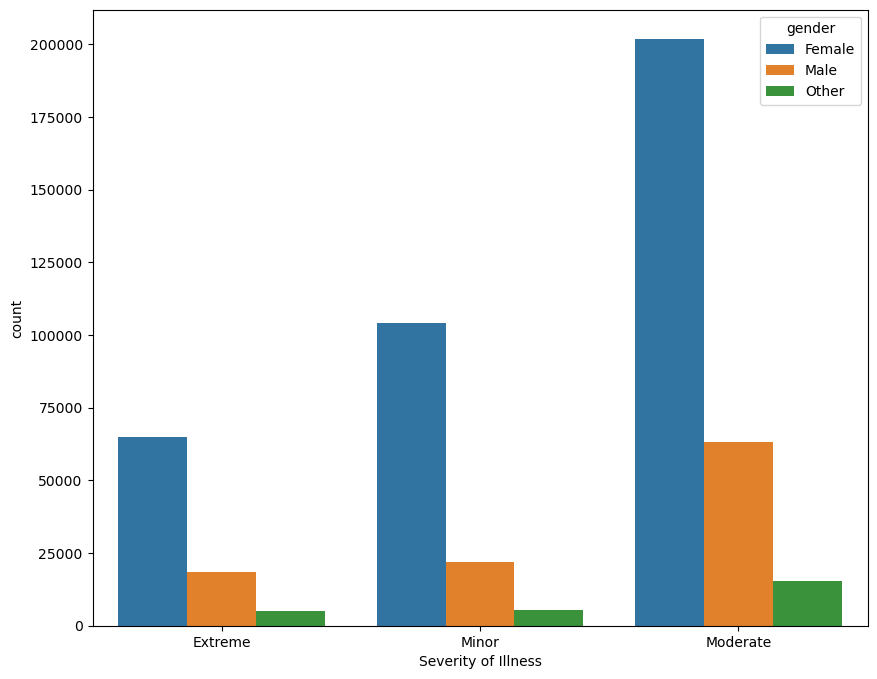

In [17]:
#plot shows illess gender data
plt.figure(figsize=(10,8))
sns.countplot(data = h4, x = 'Severity of Illness', hue = 'gender')
plt.show()

By this bar plot we can observe the majority of ' Severity of Illness' are falling under female category, comparing to male and other.

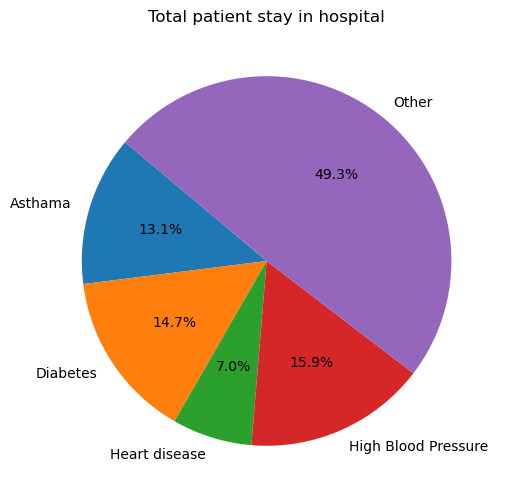

In [18]:
#pie plot for stay in days hosital accordingthrough health conditions
pie_data = h4.groupby('health_conditions')['Stay (in days)'].sum()


plt.figure(figsize=(8, 6))
plt.pie(pie_data, labels=pie_data.index, autopct='%1.1f%%', startangle=140)
plt.title("Total patient stay in hospital")
plt.show()

As the above pie chart tells majority are health conditions stays in hosiptals.

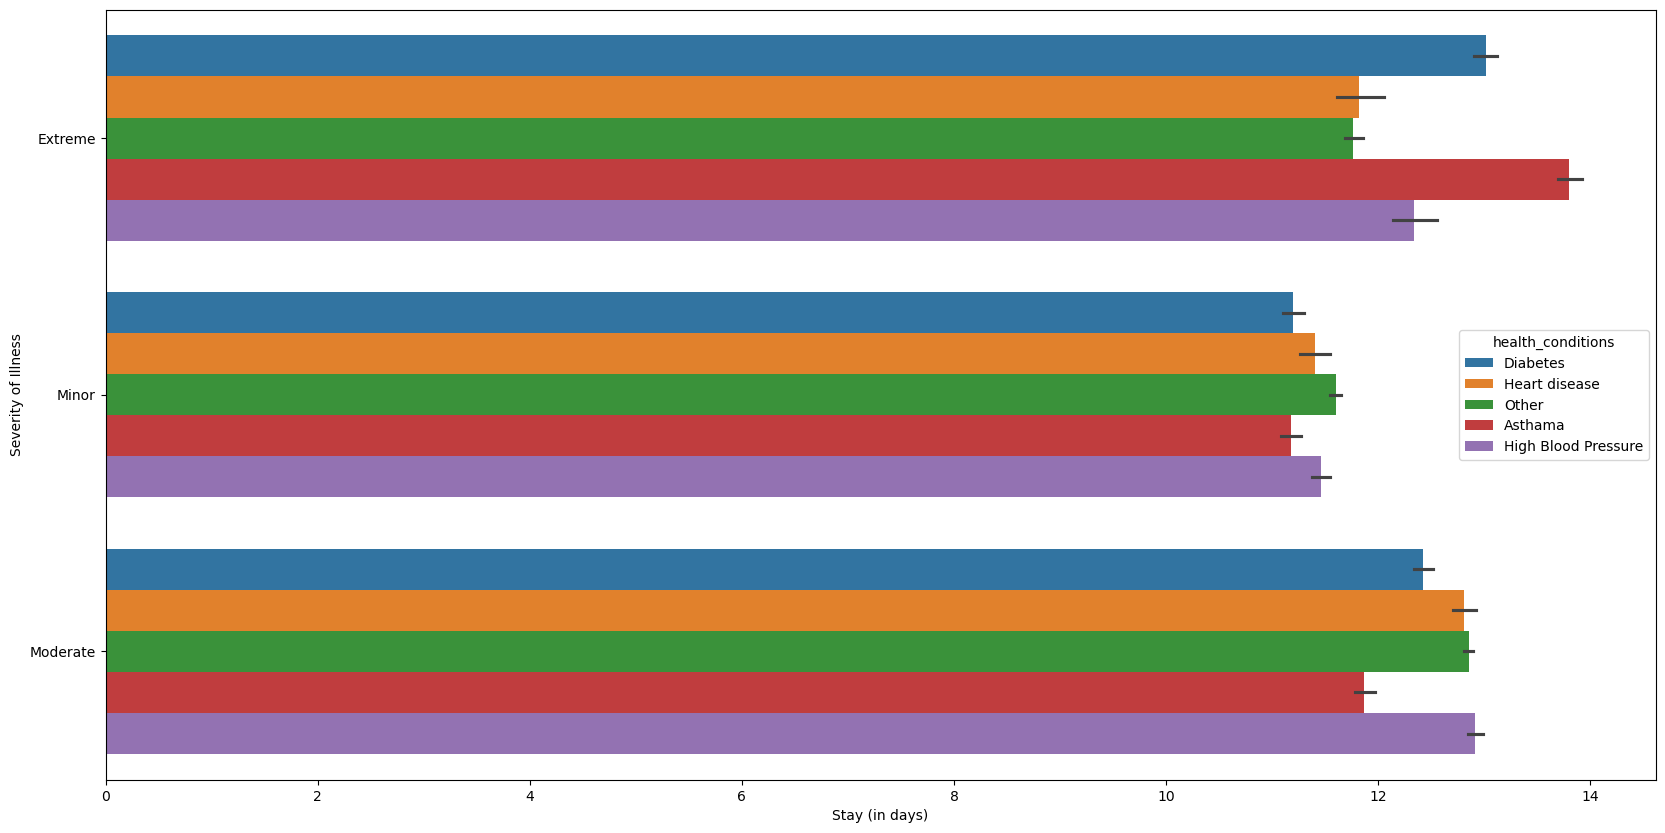

In [19]:
#Plot represents the stay in based on health conditions and severity of illness
plt.figure(figsize=(20,10))
sns.barplot(data = h4, x = 'Stay (in days)' , y = 'Severity of Illness', hue = 'health_conditions')
plt.show()


By the above plot shows the no of patients stay (in days) in hospital differentiate based of severity of illness.
Extereme Severity in health condition top in for Asthama patients.
Minor Serverity most stay falls in other (Other health conditions)
Moderate Severity falls in B.P (High Blood Pressue) health condition.


In [20]:
#Copying data into another variable
hl = h4.copy()

In [21]:
#Checking the counts of categorical columns
cols = ['Department', 'Severity of Illness', 'health_conditions']
for col in cols:
    print(f"\nValue counts for {col}:")
    print(hl[col].value_counts())


Value counts for Department:
Department
gynecology            343478
radiotherapy           84315
anesthesia             44179
TB & Chest disease     22890
surgery                 5138
Name: count, dtype: int64

Value counts for Severity of Illness:
Severity of Illness
Moderate    280197
Minor       131537
Extreme      88266
Name: count, dtype: int64

Value counts for health_conditions:
health_conditions
Other                  246299
High Blood Pressure     79402
Diabetes                73644
Asthama                 65514
Heart disease           35141
Name: count, dtype: int64


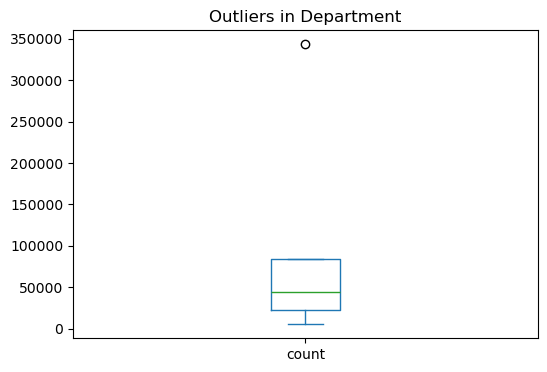

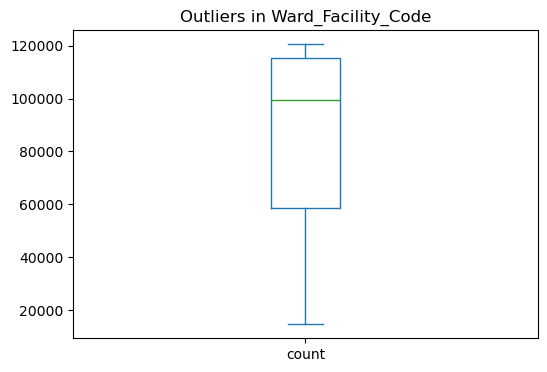

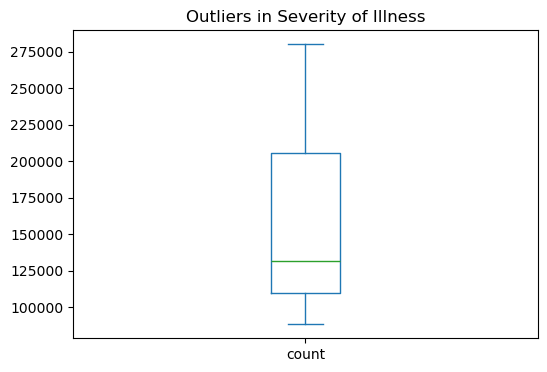

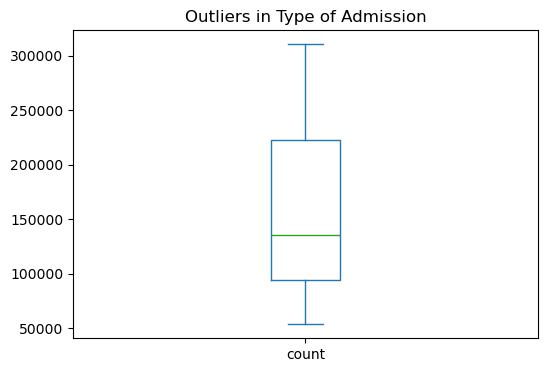

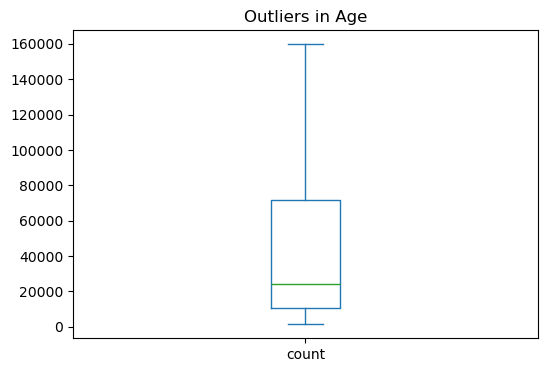

In [22]:
##Checking the outliers in categorical data using bax plot
cols = ['Department', 'Ward_Facility_Code', 'Severity of Illness', 'Type of Admission', 'Age']

for col in cols:
    value_counts = hl[col].value_counts()
    plt.figure(figsize= (6,4))
    value_counts.plot(kind = 'box')
    plt.title(f'Outliers in {col}')
    plt.show()

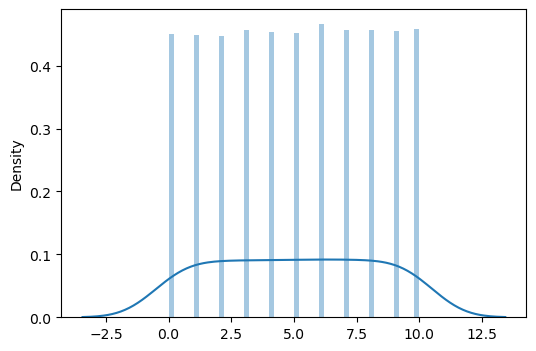

In [23]:
#Distribution of staff column
plt.figure(figsize = (6,4))
sns.distplot(x =  hl['staff_available'], kde_kws ={'bw_adjust' :5})
plt.show()

<Axes: >

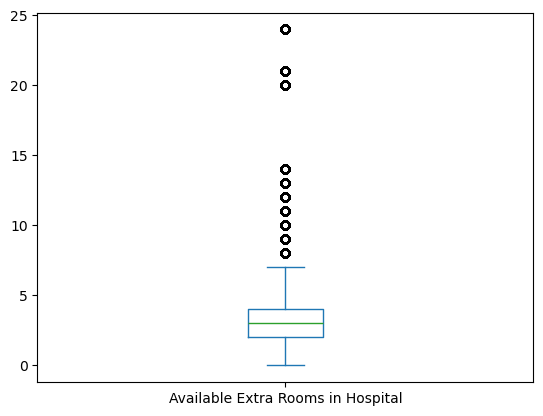

In [24]:
#Checking teh outiler extra room (numercial column) Using box plot
hl['Available Extra Rooms in Hospital'].plot(kind = 'box')

<Figure size 640x480 with 0 Axes>

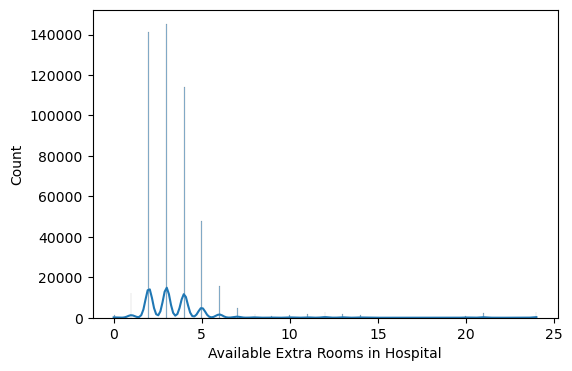

<Figure size 640x480 with 0 Axes>

In [25]:
#Checking the distribution of extra rooms column
plt.figure(figsize=(6,4))
sns.histplot(data= hl['Available Extra Rooms in Hospital'], kde = True)
plt.figure()

As the distribution of "Available Extra Rooms" in Hospital right skwed we'll use IQR Method to handle outliers.

In [26]:
#handling outliers using the IQR method
Q1 = hl['Available Extra Rooms in Hospital'].quantile(0.25)
Q3 = hl['Available Extra Rooms in Hospital'].quantile(0.75)
IQR = Q3-Q1

Lower = Q1-1.5*IQR
Upper = Q3+1.5*IQR
hl[hl['Available Extra Rooms in Hospital'] > Upper]

,Available Extra Rooms in Hospital,Department,Ward_Facility_Code,doctor_name,staff_available,patientid,Age,gender,Type of Admission,Severity of Illness,health_conditions,Visitors with Patient,Insurance,Admission_Deposit,Stay (in days)
33,10,TB & Chest disease,E,Dr John,0,24354,31-40,Female,Urgent,Extreme,Asthama,6,Yes,5029.649724,10
103,21,gynecology,D,Dr Nathan,7,50564,31-40,Female,Trauma,Minor,Other,2,No,4817.679529,10
109,8,TB & Chest disease,E,Dr Mark,2,129313,21-30,Male,Trauma,Extreme,Asthama,2,No,4841.541282,33
133,11,gynecology,F,Dr Nathan,2,42896,21-30,Female,Emergency,Minor,Other,5,Yes,5341.803592,8
142,21,anesthesia,E,Dr John,0,104672,31-40,Female,Emergency,Minor,Other,3,Yes,4477.801067,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499948,13,gynecology,B,Dr Sophia,5,106271,31-40,Female,Trauma,Moderate,Diabetes,2,No,4768.573945,10
499951,20,gynecology,D,Dr Nathan,9,17402,21-30,Female,Trauma,Minor,Other,4,No,4707.972630,10
499962,12,gynecology,D,Dr Olivia,4,41292,21-30,Female,Emergency,Moderate,Other,2,Yes,3382.589825,9
499987,12,gynecology,F,Dr Sarah,3,89272,11-20,Female,Trauma,Moderate,Asthama,2,Yes,5424.925769,9


In [27]:
hl[hl['Available Extra Rooms in Hospital'] > Upper]

,Available Extra Rooms in Hospital,Department,Ward_Facility_Code,doctor_name,staff_available,patientid,Age,gender,Type of Admission,Severity of Illness,health_conditions,Visitors with Patient,Insurance,Admission_Deposit,Stay (in days)
33,10,TB & Chest disease,E,Dr John,0,24354,31-40,Female,Urgent,Extreme,Asthama,6,Yes,5029.649724,10
103,21,gynecology,D,Dr Nathan,7,50564,31-40,Female,Trauma,Minor,Other,2,No,4817.679529,10
109,8,TB & Chest disease,E,Dr Mark,2,129313,21-30,Male,Trauma,Extreme,Asthama,2,No,4841.541282,33
133,11,gynecology,F,Dr Nathan,2,42896,21-30,Female,Emergency,Minor,Other,5,Yes,5341.803592,8
142,21,anesthesia,E,Dr John,0,104672,31-40,Female,Emergency,Minor,Other,3,Yes,4477.801067,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499948,13,gynecology,B,Dr Sophia,5,106271,31-40,Female,Trauma,Moderate,Diabetes,2,No,4768.573945,10
499951,20,gynecology,D,Dr Nathan,9,17402,21-30,Female,Trauma,Minor,Other,4,No,4707.972630,10
499962,12,gynecology,D,Dr Olivia,4,41292,21-30,Female,Emergency,Moderate,Other,2,Yes,3382.589825,9
499987,12,gynecology,F,Dr Sarah,3,89272,11-20,Female,Trauma,Moderate,Asthama,2,Yes,5424.925769,9


In [28]:
#Capping the outliers
hl['Available Extra Rooms in Hospital'] = np.where(
      hl['Available Extra Rooms in Hospital']>Upper,
     Upper,
     np.where(
          hl['Available Extra Rooms in Hospital']< Lower,
         Lower,
          hl['Available Extra Rooms in Hospital']
     )
 )       

<Axes: >

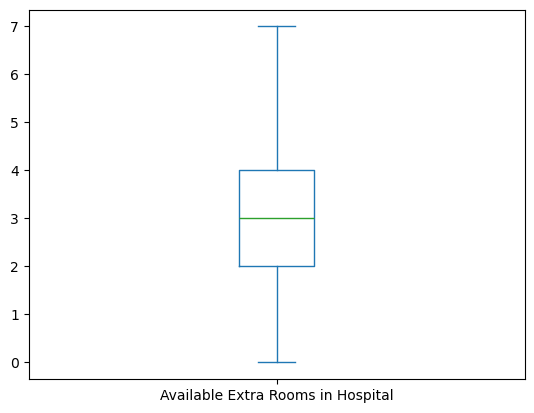

In [29]:
#No outliers in column cleaned column
hl['Available Extra Rooms in Hospital'].plot(kind = 'box')

In [30]:
#Handling the outliers in categorica data using Frequency method
def handle_categorical_outliers(hl, column, threshold=0.05, replacement='Other'):
    """
    df: your DataFrame
    column: categorical column name to clean
    threshold: minimum proportion (frequency %) to keep category
    replacement: value to replace rare categories
    """
    # Get relative frequencies (normalize=True gives proportions)
    freq = hl["Department"].value_counts(normalize=True)
    
    # Identify categories that occur less than threshold proportion
    outliers = freq[freq < threshold].index
    
    # Replace those rare categories with 'Other'
    hl["Department"] = hl["Department"].replace(outliers, replacement)
    
    return hl

# Example usage
hl_no1 = handle_categorical_outliers(hl, 'City', threshold=0.2)

In [31]:
def handle_categorical_outliers(hl, column, threshold=0.05, replacement='Other'):
    """
    df: your DataFrame
    column: categorical column name to clean
    threshold: minimum proportion (frequency %) to keep category
    replacement: value to replace rare categories
    """
    # Get relative frequencies (normalize=True gives proportions)
    freq = hl["health_conditions"].value_counts(normalize=True)
    
    # Identify categories that occur less than threshold proportion
    outliers = freq[freq < threshold].index
    
    # Replace those rare categories with 'Other'
    hl["health_conditions"] = hl["health_conditions"].replace(outliers, replacement)
    
    return hl
hl_no = handle_categorical_outliers(hl, "Department", threshold=0.01)

After the carefull consideration these are the best features for the model
Best Features
Available Extra Rooms in Hospital, Department, staff_available

In [32]:
#Copying cleaned data another variable
hzz = hl.copy()

In [33]:
hzz = hzz[['Available Extra Rooms in Hospital', 'Department','staff_available']]

In [34]:
# Readying the data for train and test splilt,X is input columns and y is target column
X = hzz[['Available Extra Rooms in Hospital', 'Department','staff_available']]
y = hzz['staff_available']

In [35]:
X

,Available Extra Rooms in Hospital,Department,staff_available
0,4.0,gynecology,0
1,4.0,gynecology,2
2,2.0,gynecology,8
3,4.0,gynecology,7
4,2.0,Other,10
...,...,...,...
499995,4.0,gynecology,2
499996,7.0,gynecology,8
499997,2.0,gynecology,3
499998,2.0,Other,1


In [36]:
from sklearn.model_selection import train_test_split #Spliting the X_train for Train and Test for testing 
from sklearn.preprocessing import OneHotEncoder #for encodeing the categorical data model only takes 1's and 0's to train model
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 42)

Spliiting the in to variable train and test split, X_train , y_train first to train the model and X_test, and y_test is for testing the trained model.

In [37]:
#Encoding the data 
ohe = OneHotEncoder(drop = 'first', sparse_output = False)
X_train = ohe.fit_transform(X_train)
X_test = ohe.fit_transform(X_test)

Encoding the data from categorical columns into split the 

In [38]:
X_train

array([[0., 1., 0., ..., 1., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.]], shape=(400000, 18))

In [39]:
from sklearn.ensemble import RandomForestRegressor #one of powerful ensemble algorithum form sklearn librabry 
rfr = RandomForestRegressor(n_estimators = 125, max_depth = 10, max_features = "sqrt", random_state = 42)
rfr.fit(X_train, y_train)

,n_estimators,125
,criterion,'squared_error'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [40]:
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error, mean_squared_error #Checking the metrics of the model.
pred = rfr.predict(X_test)


In [41]:
r2 = r2_score(y_test, pred)
mae = mean_absolute_error(y_test, pred)
rmse = root_mean_squared_error(y_test, pred)
print("R2",r2)
print("MAE", mae)
print("RMSE", rmse)

R2 0.8881799571148744
MAE 0.6362623460445347
RMSE 1.0569429205203924


In [42]:
y_train_pred = rfr.predict(X_train)
train_r2 = r2_score(y_train, y_train_pred)
print("Training R2:", train_r2)

Training R2: 0.8889133284072185
